
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 991 картинка, для которых вам будет необходимо предсказать класс.

## Шаг 1. Установка зависимостей

#### Установим необходимые библиотеки и проверим доступность CUDA

In [1]:
from typing import Mapping, Any

# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [2]:
!nvidia-smi

Tue May  5 14:19:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [56]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary
import pandas as pd

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import Subset
import torch

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


#### Проверим версии Python и библиотек
Посмотрим, какие версии установлены:

In [4]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.12.12
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


Сверим с версиями питона и библиотек, на которых работал эталонный ноутбук:

- Python 3.12.12
- torch version: 2.8.0+cu126
- torchvision version: 0.23.0+cu126
- tqdm version: 4.67.1
- matplotlib version: 3.10.0
- seaborn version: 0.13.2
- Pillow version: 11.3.0


 #### Определим константы, которые будем использовать в по ходу ноутбука

In [5]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']

# работаем на видеокарте
DEVICE = torch.device("cuda")

#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('/content/train') #Path('./data/train/')
TEST_DIR = Path('/content/testset') #Path('./data/testset')

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

## Шаг 2. Загрузка и обработка данных

#### Скачаем изображения по ссылке

In [6]:
!pip install -q gdown

In [7]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=2ca3bad4-0e2b-403f-b99e-5c70c92bdb7f
To: /kaggle/working/journey-springfield.zip
100%|████████████████████████████████████████| 546M/546M [00:07<00:00, 75.5MB/s]


In [8]:
!unzip -q /kaggle/working/journey-springfield.zip

In [9]:
base_transform = v2.Compose([
    v2.Resize(RESCALE_SIZE),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

train_dataset = ImageFolder('./train/simpsons_dataset', transform=base_transform)
test_set = ImageFolder('./testset', transform=base_transform)

labels = [label for _, label in train_dataset]

tr_idx, val_idx = train_test_split(range(len(train_dataset)), test_size=0.2, stratify=labels, random_state=42)

train_set, val_set = Subset(train_dataset, tr_idx), Subset(train_dataset, val_idx)

In [10]:
class Pass:
    def inverse_transform(self, labels):
        if hasattr(train_dataset, "classes"):
            classes = train_dataset.classes
        else:
            classes = train_dataset.dataset.classes

        return [classes[int(label)] for label in labels]

label_encoder = Pass()

In [11]:
batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=3, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=3, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=3, pin_memory=True)
loaders = {'train': train_loader, 'valid': val_loader}

#### Посмотрим на изображения персонажей

Напишем функцию для визуализации картинок. Это аналог Imshow, которая будет принимать на вход тензоры

In [12]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Проверим, как работает наша функция. Возьмем один батч из лоадера и подадим на вход функции первый тензор из этого батча. Заодно посмотрим, как работает кодировщик меток класса.

Числовая метка класса: 0


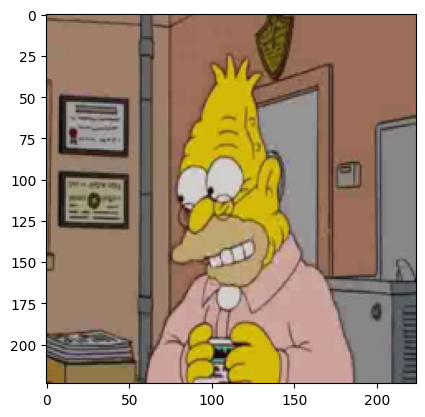

In [13]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
imshow(image_tensor[0])


Давайте посмотрим на наших героев внутри датасета.

In [14]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
  return None

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам. Очистка датасета - это один из способов повысить качество модели. Этим можно будет заняться во второй части домашнего задания.

Запустим написанную функцию.

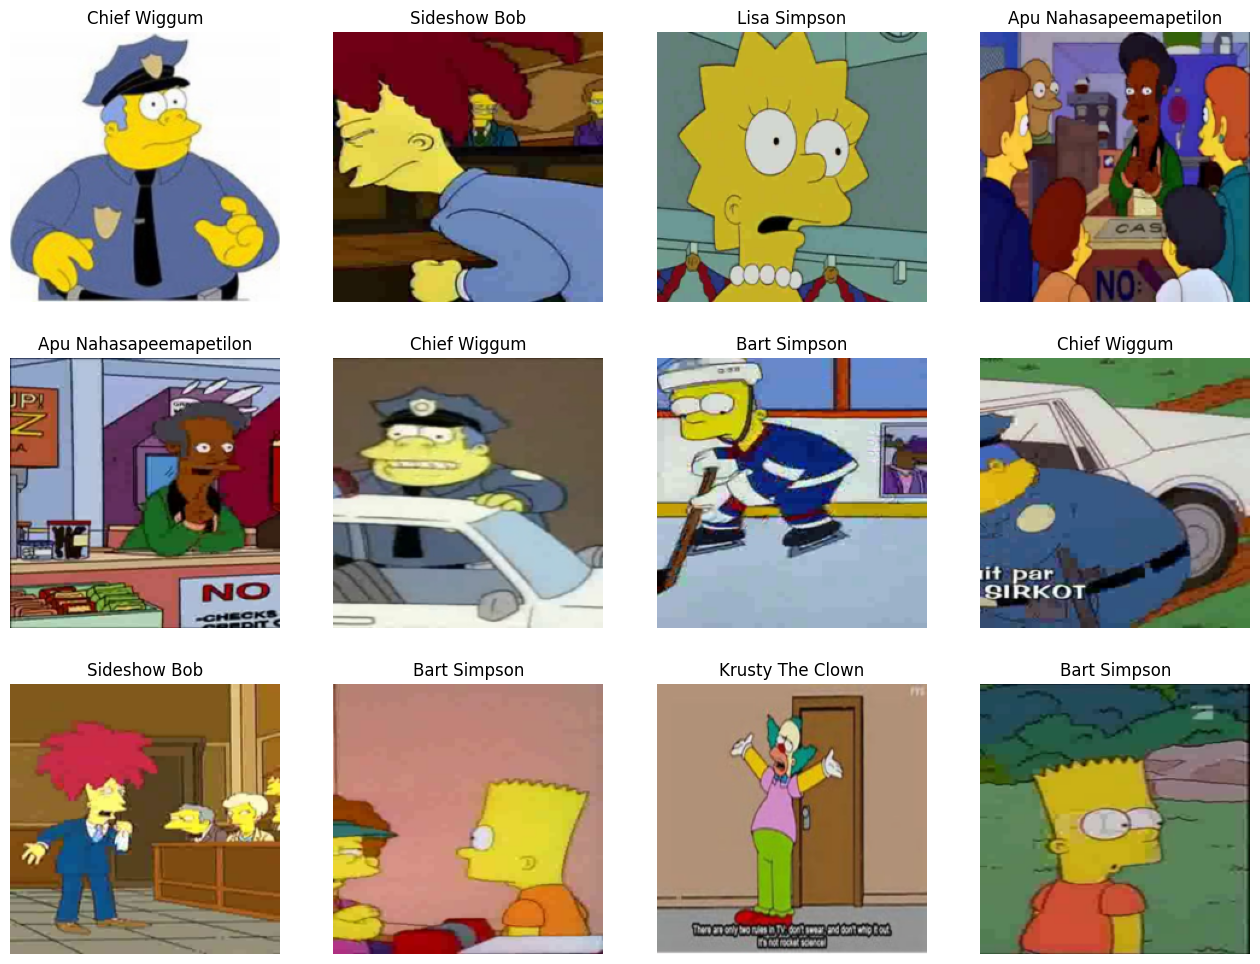

In [15]:
show_images(n_rows = 3, n_cols = 4, dataset = val_set)

## Шаг 3. Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [16]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [17]:
model_simple_cnn = SimpleCnn(n_classes = len(train_dataset.classes))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

## Шаг 4. Функции для работы с моделью

#### Задание - напишите функции для работы с моделью

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

In [18]:
!pip install catalyst

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.2 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/05/09/36a4acd1c3112f2e2da74f4340778100a205ecb59166be00dc6287f3364f/catalyst-22.4-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.0 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/28/4f/380899b95b45f02182e7163b4e9be4749724c898886d70009168bfd07409/catalyst-22.2.1-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [20]:
import collections
import collections.abc
collections.MutableMapping = collections.abc.MutableMapping

from catalyst import dl

In [21]:
# YOUR CODE
class ImgRunner(dl.Runner):
    def handle_batch(self, batch):
        x, y = batch
        preds = self.model(x)
        self.batch = {
            'logits': preds,
            'targets': y,
            'features': x
        }

## Шаг 5. Применение модели к данным

#### Применение модели к данным

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)
runner = ImgRunner()
num_epochs = 5

Запустите обучение сети

In [47]:
# YOUR CODE
runner.train(
    model=model_simple_cnn,
    criterion=criterion,
    optimizer=optimizer,
    loaders=loaders,
    logdir='./logdir',
    num_epochs=num_epochs,
    verbose=True,
    callbacks=[
        dl.CriterionCallback(input_key='logits', target_key='targets', metric_key='loss'),
        dl.OptimizerCallback(metric_key='loss'),
        dl.PrecisionRecallF1SupportCallback(input_key='logits', target_key='targets', num_classes=len(train_dataset.classes)),
    ],
    valid_metric='f1/_macro',
    minimize_valid_metric=False,
    valid_loader='valid'
)

1/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

train (1/5) f1/_macro: 0.7317461885561103 | f1/_micro: 0.7883026555912498 | f1/_weighted: 0.7857714960527272 | f1/class_00: 0.7140814730873178 | f1/class_01: 0.7586158383187769 | f1/class_02: 0.8276465313230551 | f1/class_03: 0.6394509047528325 | f1/class_04: 0.7014875373664742 | f1/class_05: 0.7432382578858867 | f1/class_06: 0.7116253779743562 | f1/class_07: 0.8725624832089437 | f1/class_08: 0.7575708723914654 | f1/class_09: 0.7457577294932122 | f1/class_10: 0.9090859504402703 | f1/class_11: 0.7853057402405134 | f1/class_12: 0.7777730247204045 | f1/class_13: 0.6666622222518517 | f1/class_14: 0.6503019293518327 | f1/class_15: 0.751726495530462 | f1/class_16: 0.8951169555305581 | f1/class_17: 0.8764218079331576 | f1/class_18: 0.6244675846505895 | f1/class_19: 0.0 | f1/class_20: 0.7200333582994141 | f1/class_21: 0.6242726172315414 | f1/class_22: 0.9162988219926529 | f1/class_23: 0.6990241832755971 | f1/class_24: 0.7176731081306033 | f1/class_25: 0.8846547463861268 | f1/class_26: 0.769225

1/5 * Epoch (valid):   0%|          | 0/17 [00:00<?, ?it/s]

valid (1/5) f1/_macro: 0.565517427589658 | f1/_micro: 0.7434867602437991 | f1/_weighted: 0.7383469402379508 | f1/class_00: 0.6987130985297233 | f1/class_01: 0.36363239673749015 | f1/class_02: 0.744961572708746 | f1/class_03: 0.24999548836267096 | f1/class_04: 0.6781361660034643 | f1/class_05: 0.6470539792750214 | f1/class_06: 0.6551674183830644 | f1/class_07: 0.8109289933417587 | f1/class_08: 0.6315739612582006 | f1/class_09: 0.6850778804429636 | f1/class_10: 0.6666622222518517 | f1/class_11: 0.7415680362664767 | f1/class_12: 0.0 | f1/class_13: 0.2857102041399408 | f1/class_14: 0.4864819284576072 | f1/class_15: 0.7368371115790096 | f1/class_16: 0.8348574194386786 | f1/class_17: 0.8706315508637669 | f1/class_18: 0.5797051964295551 | f1/class_19: 0.0 | f1/class_20: 0.6987902197897392 | f1/class_21: 0.44444043213498763 | f1/class_22: 0.9138226611411046 | f1/class_23: 0.3333298765790577 | f1/class_24: 0.5263107945072386 | f1/class_25: 0.8571378776770143 | f1/class_26: 0.0 | f1/class_27: 0.

2/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

...

valid (4/5) f1/_macro: 0.6551334468713704 | f1/_micro: 0.777878926471116 | f1/_weighted: 0.7734615771443704 | f1/class_00: 0.758059517462722 | f1/class_01: 0.428566530668221 | f1/class_02: 0.8127440040941861 | f1/class_03: 0.3636317355960924 | f1/class_04: 0.6709628585394155 | f1/class_05: 0.684205540202541 | f1/class_06: 0.7212339546315043 | f1/class_07: 0.8716657127899635 | f1/class_08: 0.6666618667012265 | f1/class_09: 0.7613586596399692 | f1/class_10: 0.6666622222518517 | f1/class_11: 0.7647009405355885 | f1/class_12: 0.5714244898250728 | f1/class_13: 0.22221728406035418 | f1/class_14: 0.666661932972468 | f1/class_15: 0.7416780481981317 | f1/class_16: 0.8866945085093391 | f1/class_17: 0.8965467266549977 | f1/class_18: 0.6226366536512545 | f1/class_19: 0.0 | f1/class_20: 0.7064976474973973 | f1/class_21: 0.6666619501467472 | f1/class_22: 0.91809023959184 | f1/class_23: 0.60869088850609 | f1/class_24: 0.6206847351427124 | f1/class_25: 0.8385492252873702 | f1/class_26: 0.0 | f1/class_

5/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

train (5/5) f1/_macro: 0.9289133266673456 | f1/_micro: 0.9062412677930227 | f1/_weighted: 0.9059830594286121 | f1/class_00: 0.8766500538108695 | f1/class_01: 0.9850696280048727 | f1/class_02: 0.9355747828190442 | f1/class_03: 0.9124950195584335 | f1/class_04: 0.8428924605838806 | f1/class_05: 0.9681478664707064 | f1/class_06: 0.8529515672839133 | f1/class_07: 0.9307006580557646 | f1/class_08: 0.9999950000249999 | f1/class_09: 0.8952330973484629 | f1/class_10: 0.9999950000249999 | f1/class_11: 0.9251650681375305 | f1/class_12: 0.9999950000249999 | f1/class_13: 0.9767391887762434 | f1/class_14: 0.9109897656588533 | f1/class_15: 0.874823815270816 | f1/class_16: 0.9548822181027001 | f1/class_17: 0.9526185368442699 | f1/class_18: 0.8388379783099383 | f1/class_19: 0.9999950000249999 | f1/class_20: 0.855674702428742 | f1/class_21: 0.857137865501789 | f1/class_22: 0.9691367551628689 | f1/class_23: 0.9090859157299065 | f1/class_24: 0.890620003418874 | f1/class_25: 0.9555120422400353 | f1/class_

5/5 * Epoch (valid):   0%|          | 0/17 [00:00<?, ?it/s]

valid (5/5) f1/_macro: 0.6458571980033292 | f1/_micro: 0.7876711404664175 | f1/_weighted: 0.784711322283226 | f1/class_00: 0.8010999730173716 | f1/class_01: 0.428566530668221 | f1/class_02: 0.8212877879121456 | f1/class_03: 0.388884027838541 | f1/class_04: 0.7366362240301727 | f1/class_05: 0.6363586777245891 | f1/class_06: 0.7139192714308077 | f1/class_07: 0.8537686099657994 | f1/class_08: 0.7058773702773862 | f1/class_09: 0.7459409472942709 | f1/class_10: 0.6666622222518517 | f1/class_11: 0.737425169036098 | f1/class_12: 0.5714244898250728 | f1/class_13: 0.2857102041399408 | f1/class_14: 0.5789427147188482 | f1/class_15: 0.7960258715270191 | f1/class_16: 0.8638447839119932 | f1/class_17: 0.9030877837241412 | f1/class_18: 0.5759950003633968 | f1/class_19: 0.0 | f1/class_20: 0.759536990665667 | f1/class_21: 0.6666622222518517 | f1/class_22: 0.9179637503324063 | f1/class_23: 0.46153349117778736 | f1/class_24: 0.6086906734811761 | f1/class_25: 0.8536535510106757 | f1/class_26: 0.0 | f1/cl

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах.

In [23]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in axs.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # выводим изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

    # ниже представлен код для добавления на изображение подписи с вероятностью класса
    actual_text = "Actual : {}".format(img_label)


    font0 = FontProperties()
    font = font0.copy()

    # наша модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100 # берем максимальную вероятность класса
    y_pred = np.argmax(prob_pred) # берем числовую метку класса, для которого вероятность максимальна

    predicted_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

In [25]:
%matplotlib inline

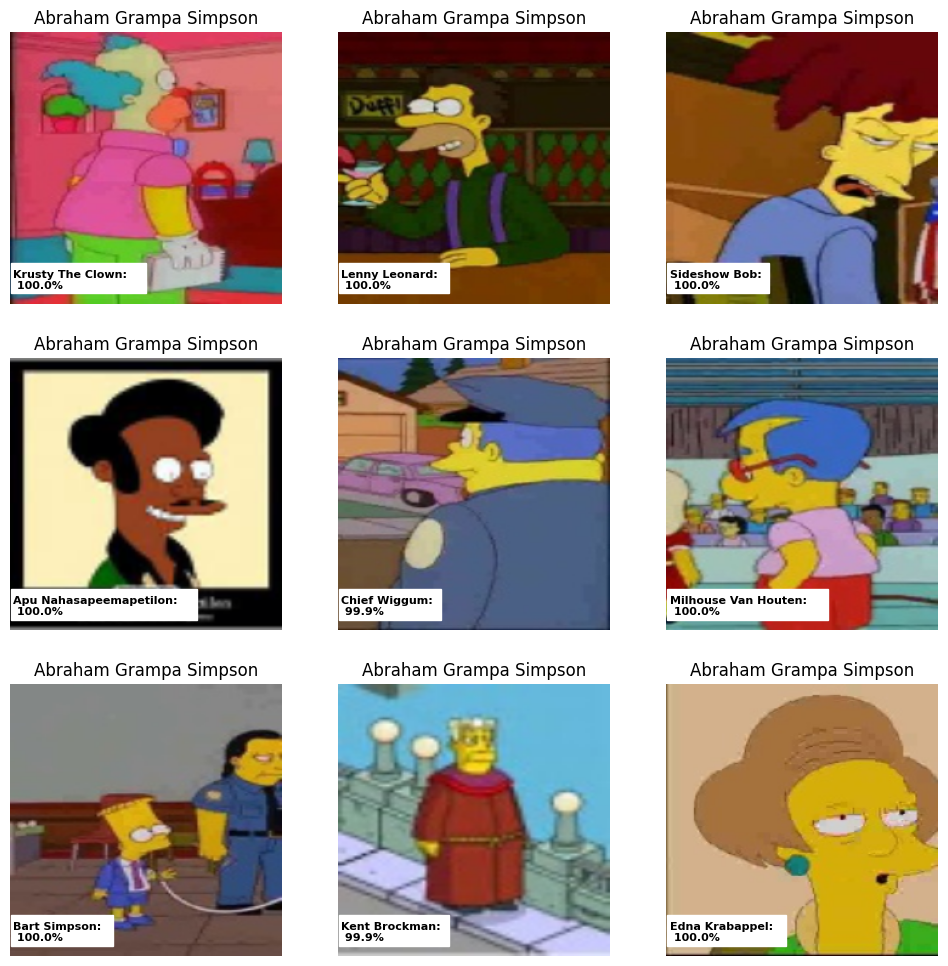

In [61]:
show_images2(n_rows = 3, n_cols = 3, dataset = test_set, model = model)

## Шаг 6. Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [54]:
def predict(model, loader):
    model.eval()
    all_predictions = []

    print("Test mode...")

    for batch in tqdm_notebook(loader):
        if isinstance(batch, (list, tuple)):
            inputs = batch[0]
        else:
            inputs = batch

        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)
            predictions = outputs.argmax(dim=-1)

        all_predictions.append(predictions.cpu())

    return torch.cat(all_predictions, dim=0)

Получем предсказание меток классов для тестовых данных:

In [72]:
from pathlib import Path

predicted_numeric_labels = predict(model_simple_cnn, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)
test_files = [Path(path) for path, _ in test_set.samples]
my_submission = pd.DataFrame({
    "Id": [path.name for path in test_files],
    "Expected": predicted_text_labels
})

Test mode...


  0%|          | 0/4 [00:00<?, ?it/s]

In [73]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

## Шаг 7. Эксперименты

In [35]:
train_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(15),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

valid_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_dataset = ImageFolder('./train/simpsons_dataset', transform=train_transform)
test_set = ImageFolder('./testset', transform=valid_transform)

tr_idx, val_idx = train_test_split(range(len(train_dataset)), random_state=42, test_size=0.2, stratify=labels)

train_set, val_set = Subset(train_dataset, tr_idx), Subset(train_dataset, val_idx)

train_loader = DataLoader(train_set, shuffle=True, batch_size=batch_size, num_workers=3, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, num_workers=3, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size, num_workers=3, pin_memory=True)

loaders = {'train': train_loader, 'valid': val_loader}

In [39]:
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.to(DEVICE)

for p in model.parameters():
    p.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(in_features=1280, out_features=len(train_dataset.classes)),
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
runner = ImgRunner()
num_epochs = 5

In [40]:
# YOUR CODE
runner.train(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    loaders=loaders,
    logdir='./logdir',
    num_epochs=num_epochs,
    verbose=True,
    callbacks=[
        dl.CriterionCallback(input_key='logits', target_key='targets', metric_key='loss'),
        dl.OptimizerCallback(metric_key='loss'),
        dl.PrecisionRecallF1SupportCallback(input_key='logits', target_key='targets', num_classes=len(train_dataset.classes)),
    ],
    valid_metric='f1/_micro',
    minimize_valid_metric=False,
    valid_loader='valid'
)

1/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

train (1/5) f1/_macro: 0.16440719179464813 | f1/_micro: 0.3782345796671936 | f1/_weighted: 0.3649132878242239 | f1/class_00: 0.38094747864423495 | f1/class_01: 0.0 | f1/class_02: 0.49609932687628877 | f1/class_03: 0.0 | f1/class_04: 0.35063729811377287 | f1/class_05: 0.022219911351441607 | f1/class_06: 0.3993959099618159 | f1/class_07: 0.5236002331504875 | f1/class_08: 0.0 | f1/class_09: 0.2415221582781344 | f1/class_10: 0.0 | f1/class_11: 0.1184482524089645 | f1/class_12: 0.0 | f1/class_13: 0.0 | f1/class_14: 0.0 | f1/class_15: 0.3467578413216392 | f1/class_16: 0.46421914303254036 | f1/class_17: 0.508138333936395 | f1/class_18: 0.0 | f1/class_19: 0.0 | f1/class_20: 0.44668088715724763 | f1/class_21: 0.0 | f1/class_22: 0.3995677033323321 | f1/class_23: 0.0 | f1/class_24: 0.0 | f1/class_25: 0.47294100883708184 | f1/class_26: 0.0 | f1/class_27: 0.37315624438233863 | f1/class_28: 0.41444039988835185 | f1/class_29: 0.020407633869996722 | f1/class_30: 0.0 | f1/class_31: 0.0 | f1/class_32: 0

1/5 * Epoch (valid):   0%|          | 0/17 [00:00<?, ?it/s]

valid (1/5) f1/_macro: 0.2520837605901742 | f1/_micro: 0.5691375842330821 | f1/_weighted: 0.5382501371310984 | f1/class_00: 0.6556423832997418 | f1/class_01: 0.0 | f1/class_02: 0.7335857396622071 | f1/class_03: 0.0 | f1/class_04: 0.5214102700839065 | f1/class_05: 0.0 | f1/class_06: 0.5232017514586955 | f1/class_07: 0.7253836032184124 | f1/class_08: 0.0 | f1/class_09: 0.49253312545329775 | f1/class_10: 0.0 | f1/class_11: 0.37704538971830226 | f1/class_12: 0.0 | f1/class_13: 0.0 | f1/class_14: 0.15384473374091936 | f1/class_15: 0.5514957746448975 | f1/class_16: 0.7111061728737995 | f1/class_17: 0.7045822228104003 | f1/class_18: 0.031249394542980705 | f1/class_19: 0.0 | f1/class_20: 0.5989060721561067 | f1/class_21: 0.0 | f1/class_22: 0.5708283615016372 | f1/class_23: 0.0 | f1/class_24: 0.03999960800384161 | f1/class_25: 0.6619335365801607 | f1/class_26: 0.0 | f1/class_27: 0.5530593596393616 | f1/class_28: 0.595131048563942 | f1/class_29: 0.10256268246542231 | f1/class_30: 0.0 | f1/class_

2/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

...

valid (4/5) f1/_macro: 0.4286153440590206 | f1/_micro: 0.6914208419277259 | f1/_weighted: 0.6767457520752426 | f1/class_00: 0.7420097927875707 | f1/class_01: 0.0 | f1/class_02: 0.8416938477659487 | f1/class_03: 0.29629283954650165 | f1/class_04: 0.6366856539908223 | f1/class_05: 0.5624953125390622 | f1/class_06: 0.6694336696705122 | f1/class_07: 0.7558635728467381 | f1/class_08: 0.3636333884540944 | f1/class_09: 0.6551674461996416 | f1/class_10: 0.0 | f1/class_11: 0.7441810634460222 | f1/class_12: 0.0 | f1/class_13: 0.0 | f1/class_14: 0.7142808163601163 | f1/class_15: 0.7009394028380875 | f1/class_16: 0.8040151006598639 | f1/class_17: 0.8059100317713292 | f1/class_18: 0.4893572114490864 | f1/class_19: 0.0 | f1/class_20: 0.6764655883398316 | f1/class_21: 0.07407336077504434 | f1/class_22: 0.6480397004223425 | f1/class_23: 0.13333208890050352 | f1/class_24: 0.61332880358901 | f1/class_25: 0.7346888796674853 | f1/class_26: 0.0 | f1/class_27: 0.6699457487813757 | f1/class_28: 0.71428074334

5/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

train (5/5) f1/_macro: 0.4373790880718092 | f1/_micro: 0.687383032999465 | f1/_weighted: 0.6744029969863778 | f1/class_00: 0.6991277585903344 | f1/class_01: 0.0 | f1/class_02: 0.8257009442158847 | f1/class_03: 0.2941148693072801 | f1/class_04: 0.6485931309495399 | f1/class_05: 0.7407358617605312 | f1/class_06: 0.681604784909286 | f1/class_07: 0.7373444098247108 | f1/class_08: 0.3043449527681478 | f1/class_09: 0.6657408628392618 | f1/class_10: 0.0 | f1/class_11: 0.6907944508724798 | f1/class_12: 0.0869556899890522 | f1/class_13: 0.0869556899890522 | f1/class_14: 0.5859825388834444 | f1/class_15: 0.6969725508253413 | f1/class_16: 0.8221599518052632 | f1/class_17: 0.7860550410590347 | f1/class_18: 0.490561605375667 | f1/class_19: 0.0 | f1/class_20: 0.6780651879752815 | f1/class_21: 0.15789285320806704 | f1/class_22: 0.6603211076739748 | f1/class_23: 0.03448241974173712 | f1/class_24: 0.5423684445062756 | f1/class_25: 0.7335857451383022 | f1/class_26: 0.0 | f1/class_27: 0.6661086526408272 

5/5 * Epoch (valid):   0%|          | 0/17 [00:00<?, ?it/s]

valid (5/5) f1/_macro: 0.4544584924023145 | f1/_micro: 0.7026460628490496 | f1/_weighted: 0.6901107584924249 | f1/class_00: 0.7579412655674956 | f1/class_01: 0.0 | f1/class_02: 0.8524540194461148 | f1/class_03: 0.24999781251914055 | f1/class_04: 0.6529030677389024 | f1/class_05: 0.68749531253196 | f1/class_06: 0.6902605033056157 | f1/class_07: 0.7517034808156631 | f1/class_08: 0.49999625002812476 | f1/class_09: 0.7045404778244106 | f1/class_10: 0.0 | f1/class_11: 0.7630007939114345 | f1/class_12: 0.0 | f1/class_13: 0.0 | f1/class_14: 0.5499952000418905 | f1/class_15: 0.6782381394732131 | f1/class_16: 0.8316781688370329 | f1/class_17: 0.8068783959593716 | f1/class_18: 0.585853904741005 | f1/class_19: 0.0 | f1/class_20: 0.681734146940021 | f1/class_21: 0.07142724492259425 | f1/class_22: 0.6480397004223425 | f1/class_23: 0.13333208890050352 | f1/class_24: 0.6585317757638598 | f1/class_25: 0.7720040324605336 | f1/class_26: 0.0 | f1/class_27: 0.6752777319562374 | f1/class_28: 0.727569756383

In [41]:
for p in model.parameters():
    p.requires_grad = True

runner.train(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    loaders=loaders,
    logdir='./logdir',
    num_epochs=num_epochs,
    verbose=True,
    callbacks=[
        dl.CriterionCallback(input_key='logits', target_key='targets', metric_key='loss'),
        dl.OptimizerCallback(metric_key='loss'),
        dl.PrecisionRecallF1SupportCallback(input_key='logits', target_key='targets', num_classes=len(train_dataset.classes)),
    ],
    valid_metric='f1/_micro',
    minimize_valid_metric=False,
    valid_loader='valid'
)

1/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

train (1/5) f1/_macro: 0.7467167154730779 | f1/_micro: 0.918184418395793 | f1/_weighted: 0.9157622466425792 | f1/class_00: 0.9187663311434716 | f1/class_01: 0.6666620027761122 | f1/class_02: 0.9648191206339766 | f1/class_03: 0.7741885952450088 | f1/class_04: 0.9509524965767008 | f1/class_05: 0.9150276816881998 | f1/class_06: 0.9075754781381957 | f1/class_07: 0.9076205448491377 | f1/class_08: 0.7692259124567004 | f1/class_09: 0.9039950000276548 | f1/class_10: 0.0 | f1/class_11: 0.9171220724609387 | f1/class_12: 0.4848440404447808 | f1/class_13: 0.2222192044305571 | f1/class_14: 0.893612026397317 | f1/class_15: 0.9225650173700588 | f1/class_16: 0.9464458098708758 | f1/class_17: 0.9545636586001972 | f1/class_18: 0.8531137123231879 | f1/class_19: 0.0 | f1/class_20: 0.9396107369501671 | f1/class_21: 0.6823481412102359 | f1/class_22: 0.9563080104407861 | f1/class_23: 0.7128663699976457 | f1/class_24: 0.8295115395027142 | f1/class_25: 0.9476058234853906 | f1/class_26: 0.24999781251914055 | f1

1/5 * Epoch (valid):   0%|          | 0/17 [00:00<?, ?it/s]

valid (1/5) f1/_macro: 0.8103307860941478 | f1/_micro: 0.9548552818508772 | f1/_weighted: 0.9534002954589461 | f1/class_00: 0.9602072058741998 | f1/class_01: 0.7619000453806715 | f1/class_02: 0.9919304842213497 | f1/class_03: 0.7999952000287999 | f1/class_04: 0.9795868369151072 | f1/class_05: 0.9473634349292899 | f1/class_06: 0.9409140477834494 | f1/class_07: 0.9618270611270671 | f1/class_08: 0.9411714879156522 | f1/class_09: 0.9450499505154673 | f1/class_10: 0.0 | f1/class_11: 0.9673863049643997 | f1/class_12: 0.5714244898250728 | f1/class_13: 0.0 | f1/class_14: 0.9166616666939391 | f1/class_15: 0.9578663970202134 | f1/class_16: 0.9599950000260415 | f1/class_17: 0.9895999896518631 | f1/class_18: 0.9401659580949229 | f1/class_19: 0.0 | f1/class_20: 0.9725726969699768 | f1/class_21: 0.8510588864026384 | f1/class_22: 0.9865075242771805 | f1/class_23: 0.7272680992030051 | f1/class_24: 0.88888388942716 | f1/class_25: 0.9718259869330739 | f1/class_26: 0.7999952000287999 | f1/class_27: 0.948

2/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

...

valid (4/5) f1/_macro: 0.9023938176137074 | f1/_micro: 0.9691853511124915 | f1/_weighted: 0.9689895943372656 | f1/class_00: 0.9808169178712379 | f1/class_01: 0.9999950000249999 | f1/class_02: 0.983865968092524 | f1/class_03: 0.7894687396431569 | f1/class_04: 0.9648748525786847 | f1/class_05: 0.9499950000263157 | f1/class_06: 0.9670731906810554 | f1/class_07: 0.9582259633581421 | f1/class_08: 0.8999950500272248 | f1/class_09: 0.9738169907879738 | f1/class_10: 0.6666622222518517 | f1/class_11: 0.978255870181504 | f1/class_12: 0.9999950000249999 | f1/class_13: 0.8888839506447186 | f1/class_14: 0.9387705123131553 | f1/class_15: 0.9738289045233379 | f1/class_16: 0.9751193782588483 | f1/class_17: 0.9916267995385211 | f1/class_18: 0.9448768925802138 | f1/class_19: 0.0 | f1/class_20: 0.9741647417230798 | f1/class_21: 0.901955786263759 | f1/class_22: 0.9748499323460916 | f1/class_23: 0.8333284722505785 | f1/class_24: 0.9599950020260207 | f1/class_25: 0.9791133295188064 | f1/class_26: 0.57142367

5/5 * Epoch (train):   0%|          | 0/66 [00:00<?, ?it/s]

train (5/5) f1/_macro: 0.9779113212332103 | f1/_micro: 0.9918139418620626 | f1/_weighted: 0.991794581855238 | f1/class_00: 0.986315109473828 | f1/class_01: 0.9850696280048727 | f1/class_02: 0.9929739368406381 | f1/class_03: 0.9764655882608964 | f1/class_04: 0.9958070056101802 | f1/class_05: 0.9935433873300509 | f1/class_06: 0.9884766754234435 | f1/class_07: 0.9898684177547861 | f1/class_08: 0.9729679766509307 | f1/class_09: 0.9960003262656564 | f1/class_10: 0.9999950000249999 | f1/class_11: 0.9945305191508202 | f1/class_12: 0.9767391887762434 | f1/class_13: 0.9999950000249999 | f1/class_14: 0.9897909189132157 | f1/class_15: 0.9896971987453801 | f1/class_16: 0.9937214743115735 | f1/class_17: 0.9963624105198249 | f1/class_18: 0.9858535859043501 | f1/class_19: 0.6666622222518517 | f1/class_20: 0.9958379561462632 | f1/class_21: 0.9801930203176281 | f1/class_22: 0.9956408635966714 | f1/class_23: 0.9911454428946685 | f1/class_24: 0.9822734810701549 | f1/class_25: 0.9953653704021843 | f1/clas

5/5 * Epoch (valid):   0%|          | 0/17 [00:00<?, ?it/s]

valid (5/5) f1/_macro: 0.8917732306143848 | f1/_micro: 0.9615426475062957 | f1/_weighted: 0.9615233559888556 | f1/class_00: 0.96514245486995 | f1/class_01: 0.9999950000249999 | f1/class_02: 0.9800746813797713 | f1/class_03: 0.6808461204523701 | f1/class_04: 0.9640781767048219 | f1/class_05: 0.9743539776719093 | f1/class_06: 0.9567049627329143 | f1/class_07: 0.9873367722092649 | f1/class_08: 0.818176983499643 | f1/class_09: 0.9787184042808624 | f1/class_10: 0.9999950000249999 | f1/class_11: 0.9780169780475396 | f1/class_12: 0.5714244898250728 | f1/class_13: 0.5714244898250728 | f1/class_14: 0.9583283333594202 | f1/class_15: 0.9700946679531525 | f1/class_16: 0.9849196232672185 | f1/class_17: 0.9937319522045829 | f1/class_18: 0.9841219854121376 | f1/class_19: 0.0 | f1/class_20: 0.977606940950605 | f1/class_21: 0.8333283680851401 | f1/class_22: 0.98461038493663 | f1/class_23: 0.8461488757688417 | f1/class_24: 0.9183623469659976 | f1/class_25: 0.9790159792910227 | f1/class_26: 0.99999500002

In [52]:
from catalyst import utils


ckp = utils.load_checkpoint(path='./logdir/checkpoints/train.4.pth')
utils.unpack_checkpoint(
    checkpoint=ckp,
    model=model,
)

In [62]:
predicted_numeric_labels = predict(model, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)
test_files = [Path(path) for path, _ in test_set.samples]
my_submission = pd.DataFrame({
    "Id": [path.name for path in test_files],
    "Expected": predicted_text_labels
})

my_submission.to_csv('not_a_baseline.csv', index=False)

Test mode...


  0%|          | 0/4 [00:00<?, ?it/s]

## Описание проделанной работы

В качестве модели продвинутой модели я выбрал efficientnet_b0, как максимально легкую и бысстро-обучаемую модель. Попробовал обучить только классификационную голову, а после и всю модель. Метрика на валидации после обучения только головы 0.7026. После того, как обучил модель полностью и сделал сабмит: 0.988

Также я переписал датасет симпсоно тк мне показалось костылем писать класс для обработки файла с изображениями вручную, я использовал рекомендованные торчем конструкции
Для обучения использовать библиотеку catalyst, показанную в семинаре



ps прошу прощения за логи внизу, мне было лень копаться в доках чтобы понять, как их обрезать. Тк там и так видно нужную метрику я решил ничего не трогать
ps2 после выгрузки ноутбука с кагла логи стерлись. Если есть желание посмотреть то вот ссылка https://www.kaggle.com/code/saveliymazovatov/hw-5-simpsons-classification

# Скор получился 0.98831 

Савелий_Мазоватов_595235188
На момент сдачи 244 место